# ✍️ DigitCheck — conferência assistida de campos numéricos manuscritos

**Projeto de Inteligência Artificial com TensorFlow/Keras e MNIST**

## 🎯 Problema

Números escritos em fichas, formulários e registros curtos ainda precisam ser digitados e
conferidos manualmente. O DigitCheck recebe uma imagem de uma sequência manuscrita, separa
os algarismos, sugere a leitura e destaca os casos que precisam de revisão humana.

## 📦 Produto entregue

- CNN pequena treinada para reconhecer algarismos de **0 a 9**;
- quantidade de épocas escolhida pela validação e melhor modelo salvo no Drive;
- curvas de aprendizado, matriz de confusão e relatório por algarismo;
- upload de fotografias com um ou vários dígitos em uma linha;
- limiar de revisão estimado com a validação, correção humana e exportação para CSV.

## ⚠️ Escopo

É uma prova de conceito para **campos numéricos curtos, escritos com tinta escura em papel claro,
com dígitos separados**. Não é OCR de documentos completos. A confiança da softmax não garante
que a previsão esteja correta, principalmente em fotografias diferentes do MNIST.

### Execução

Na primeira vez, execute os passos **1 a 12 em ordem**. Em outra sessão, para apenas usar o
modelo salvo, execute o passo 1 e depois os passos **9 a 12**.


## ⚙️ Passo 1 — Ambiente

O MNIST é pequeno e o modelo pode ser treinado em CPU. Uma GPU reduz o tempo, mas não é
necessária. O Drive guarda o melhor modelo e os relatórios.


In [ ]:
import os, io, re, json, time, hashlib, platform
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display
from google.colab import drive, files

drive.mount('/content/drive')
print('TensorFlow:',tf.__version__)
print('GPU:',tf.config.list_physical_devices('GPU') or 'não disponível — CPU é suficiente')


Mounted at /content/drive
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 🧭 Passo 2 — Configuração reproduzível

As imagens continuam em escala de cinza e `28 × 28`, o formato original do MNIST. O modelo
normaliza os pixels internamente. `EPOCAS_MAXIMAS` é apenas um teto: a parada antecipada escolhe
o momento de encerrar a partir da validação.

Para retomar uma execução já concluída, copie o caminho impresso em `RETOMAR_PASTA`.


In [ ]:
SEED=42
BATCH=128
EPOCAS_MAXIMAS=30
RETOMAR_PASTA=''  # Ex.: /content/drive/MyDrive/DigitCheck/20260914_180000

tf.keras.utils.set_random_seed(SEED)
RAIZ=Path('/content/drive/MyDrive/DigitCheck')
PASTA=Path(RETOMAR_PASTA) if RETOMAR_PASTA else RAIZ/datetime.now().strftime('%Y%m%d_%H%M%S_%f')
PASTA.mkdir(parents=True,exist_ok=True)
MODELO_FINAL=PASTA/'melhor_modelo.keras'

def salvar_json(caminho,objeto):
    Path(caminho).write_text(json.dumps(objeto,ensure_ascii=False,indent=2),encoding='utf-8')
def sha256(caminho):
    h=hashlib.sha256()
    with open(caminho,'rb') as f:
        for bloco in iter(lambda:f.read(1024*1024),b''): h.update(bloco)
    return h.hexdigest()

config={'seed':SEED,'batch':BATCH,'epocas_maximas':EPOCAS_MAXIMAS,
        'imagem':[28,28,1],'classes':list(range(10)),'arquitetura':'cnn_compacta_v1'}
if (PASTA/'config.json').exists():
    assert json.loads((PASTA/'config.json').read_text())==config,'Configuração diferente: use uma pasta nova.'
else: salvar_json(PASTA/'config.json',config)
salvar_json(PASTA/'ambiente.json',{'tensorflow':tf.__version__,'python':platform.python_version(),
                                   'gpu':[d.name for d in tf.config.list_physical_devices('GPU')]})
print('📁 GUARDE ESTE CAMINHO:',PASTA)


📁 GUARDE ESTE CAMINHO: /content/drive/MyDrive/DigitCheck/20260913_214546_591417


## 📥 Passo 3 — Carregar e dividir o MNIST

O dataset oficial do Keras contém 60.000 imagens de treinamento e 10.000 de teste. Separamos
10% do treinamento para validação, mantendo a proporção dos algarismos. O teste fica reservado
até a avaliação final.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Treino    : (54000, 28, 28) | rótulos: (54000,) | pixels: 0 a 255
Validação : (6000, 28, 28) | rótulos: (6000,) | pixels: 0 a 255
Teste     : (10000, 28, 28) | rótulos: (10000,) | pixels: 0 a 255


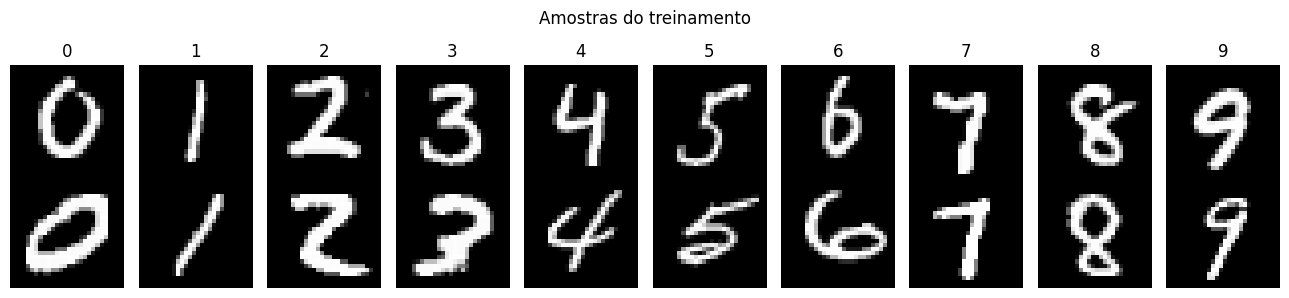

,dígito,treino,validação,teste
0,0,5331,592,980
1,1,6068,674,1135
2,2,5362,596,1032
3,3,5518,613,1010
4,4,5258,584,982
5,5,4879,542,892
6,6,5326,592,958
7,7,5638,627,1028
8,8,5266,585,974
9,9,5354,595,1009


In [ ]:
(x_base,y_base),(x_teste,y_teste)=tf.keras.datasets.mnist.load_data()
x_treino,x_val,y_treino,y_val=train_test_split(
    x_base,y_base,test_size=.10,random_state=SEED,stratify=y_base)
for nome,x,y in [('Treino',x_treino,y_treino),('Validação',x_val,y_val),('Teste',x_teste,y_teste)]:
    print(f'{nome:10s}: {x.shape} | rótulos: {y.shape} | pixels: {x.min()} a {x.max()}')

fig,axs=plt.subplots(2,10,figsize=(13,3))
rng=np.random.default_rng(SEED)
for digito in range(10):
    ids=np.flatnonzero(y_treino==digito)
    for linha,idx in enumerate(rng.choice(ids,2,replace=False)):
        axs[linha,digito].imshow(x_treino[idx],cmap='gray'); axs[linha,digito].axis('off')
        if linha==0: axs[linha,digito].set_title(str(digito))
plt.suptitle('Amostras do treinamento'); plt.tight_layout(); plt.show()

dist=pd.DataFrame({'dígito':range(10),'treino':[np.sum(y_treino==i) for i in range(10)],
                   'validação':[np.sum(y_val==i) for i in range(10)],
                   'teste':[np.sum(y_teste==i) for i in range(10)]})
display(dist)


## 🧠 Passo 4 — Construir uma CNN compacta

A rede usa duas convoluções para aprender traços e formas. O `GlobalAveragePooling2D` reduz
parâmetros em comparação com uma grande camada `Flatten`. Pequenas translações e rotações são
aplicadas somente durante o treino para reduzir sensibilidade ao posicionamento.


In [ ]:
def construir_modelo():
    return tf.keras.Sequential([
        tf.keras.layers.Input((28,28,1),name='imagem_0_255'),
        tf.keras.layers.Rescaling(1/255),
        tf.keras.layers.RandomTranslation(.08,.08,fill_mode='constant',seed=SEED),
        tf.keras.layers.RandomRotation(.05,fill_mode='constant',seed=SEED),
        tf.keras.layers.Conv2D(16,3,padding='same',activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32,3,padding='same',activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64,3,padding='same',activation='relu'),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(32,activation='relu'),
        tf.keras.layers.Dropout(.20),
        tf.keras.layers.Dense(10,activation='softmax',name='digito')
    ],name='DigitCheck_CNN')

modelo=construir_modelo()
modelo.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss='sparse_categorical_crossentropy',metrics=['accuracy'])
modelo.summary()
print('Parâmetros:',f'{modelo.count_params():,}')

# Teste estrutural, sem afirmar qualidade.
amostra=x_treino[:4,...,None].astype('float32')
probs=modelo(amostra,training=False).numpy()
assert probs.shape==(4,10) and np.isfinite(probs).all()
np.testing.assert_allclose(probs.sum(1),1,atol=1e-5)
print('✅ Formato e probabilidades verificados.')


Model: "DigitCheck_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digito (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,706 (100.41 KB)

 Trainable params: 25,706 (100.41 KB)

 Non-trainable params: 0 (0.00 B)

Parâmetros: 25,706
✅ Formato e probabilidades verificados.


## 🏋️ Passo 5 — Treinar, descobrir a melhor época e salvar

O checkpoint monitora `val_accuracy`. A taxa de aprendizado diminui após duas épocas sem redução
da loss de validação. O treinamento para após quatro épocas sem melhora relevante de acurácia e
restaura o melhor estado. Assim, não escolhemos 30 épocas antecipadamente nem usamos o teste para
decidir quando parar.


In [ ]:
HISTORICO=PASTA/'historico.csv'
RESUMO=PASTA/'treinamento.json'
if MODELO_FINAL.exists() and HISTORICO.exists() and RESUMO.exists():
    print('♻️ Treinamento concluído encontrado; carregando o melhor modelo.')
    modelo=tf.keras.models.load_model(MODELO_FINAL,compile=False)
    registro=json.loads(RESUMO.read_text())
else:
    if MODELO_FINAL.exists() or HISTORICO.exists():
        raise RuntimeError('Execução anterior incompleta preservada. Use uma pasta nova para treinar novamente.')
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(str(MODELO_FINAL),monitor='val_accuracy',mode='max',
                                           save_best_only=True,verbose=1),
        tf.keras.callbacks.CSVLogger(str(HISTORICO)),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',mode='min',factor=.5,patience=2,
                                             min_delta=0,min_lr=1e-6,verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',mode='max',patience=4,
                                         min_delta=.0002,restore_best_weights=True,verbose=1),
        tf.keras.callbacks.TerminateOnNaN()]
    inicio=time.perf_counter()
    modelo.fit(x_treino[...,None],y_treino,validation_data=(x_val[...,None],y_val),
               epochs=EPOCAS_MAXIMAS,batch_size=BATCH,callbacks=callbacks,verbose=2,shuffle=True)
    segundos=time.perf_counter()-inicio
    h=pd.read_csv(HISTORICO)
    assert MODELO_FINAL.exists() and np.isfinite(h[['loss','val_loss','accuracy','val_accuracy']]).all().all()
    melhor=int(h.val_accuracy.idxmax())
    registro={'melhor_epoca':int(h.loc[melhor,'epoch'])+1,
              'melhor_val_accuracy':float(h.loc[melhor,'val_accuracy']),
              'epocas_executadas':len(h),'treinamento_segundos':segundos,
              'modelo_sha256':sha256(MODELO_FINAL)}
    salvar_json(RESUMO,registro)
    modelo=tf.keras.models.load_model(MODELO_FINAL,compile=False)
print('✅ Melhor modelo:',MODELO_FINAL)
print(registro)


Epoch 1/30

Epoch 1: val_accuracy improved from None to 0.74617, saving model to /content/drive/MyDrive/DigitCheck/20260913_214546_591417/melhor_modelo.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DigitCheck/20260913_214546_591417/melhor_modelo.keras
422/422 - 10s - 23ms/step - accuracy: 0.4277 - loss: 1.5499 - val_accuracy: 0.7462 - val_loss: 0.7963 - learning_rate: 0.0010
Epoch 2/30

Epoch 2: val_accuracy improved from 0.74617 to 0.88533, saving model to /content/drive/MyDrive/DigitCheck/20260913_214546_591417/melhor_modelo.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DigitCheck/20260913_214546_591417/melhor_modelo.keras
422/422 - 6s - 13ms/step - accuracy: 0.7444 - loss: 0.7743 - val_accuracy: 0.8853 - val_loss: 0.3867 - learning_rate: 0.0010
Epoch 3/30

Epoch 3: val_accuracy improved from 0.88533 to 0.91767, saving model to /content/drive/MyDrive/DigitCheck/20260913_214546_591417/melhor_modelo.keras

Epoch 3: finished saving model to /content/d

## 📈 Passo 6 — Curvas e custo computacional

As curvas permitem observar quando a validação parou de melhorar. A linha pontilhada mostra a
época selecionada. O tempo de inferência é medido no hardware desta sessão e pode variar.


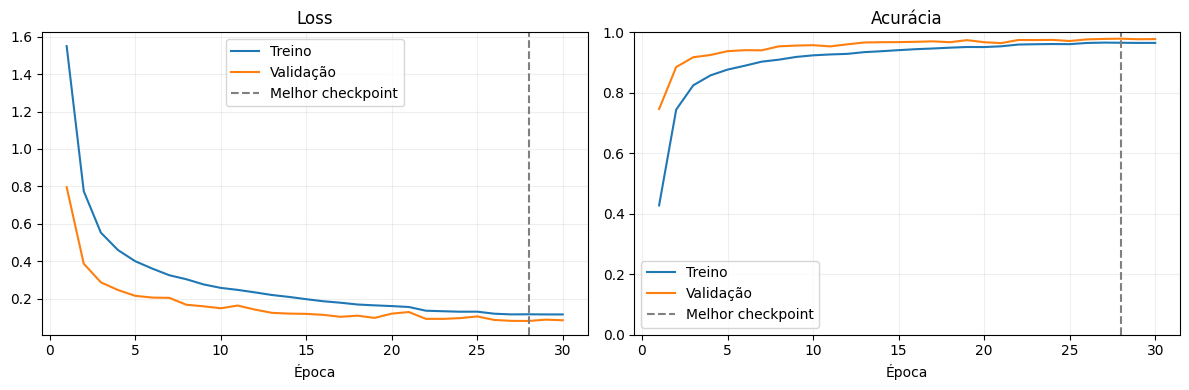

,parametros,modelo_mb,treino_segundos,inferencia_mediana_ms,resolucao,canais
0,25706,0.344155,120.658108,11.380122,28x28,1


In [ ]:
h=pd.read_csv(HISTORICO)
fig,axs=plt.subplots(1,2,figsize=(12,4))
for ax,metrica,titulo in zip(axs,['loss','accuracy'],['Loss','Acurácia']):
    ax.plot(h.epoch+1,h[metrica],label='Treino')
    ax.plot(h.epoch+1,h['val_'+metrica],label='Validação')
    ax.axvline(registro['melhor_epoca'],ls='--',color='gray',label='Melhor checkpoint')
    ax.set(xlabel='Época',title=titulo); ax.grid(alpha=.2); ax.legend()
axs[1].set_ylim(0,1)
plt.tight_layout(); plt.savefig(PASTA/'curvas.png',dpi=150); plt.show()

entrada=x_val[:1,...,None].astype('float32')
for _ in range(5): modelo(entrada,training=False).numpy()
tempos=[]
for _ in range(30):
    t=time.perf_counter(); modelo(entrada,training=False).numpy(); tempos.append(time.perf_counter()-t)
custo={'parametros':int(modelo.count_params()),'modelo_mb':MODELO_FINAL.stat().st_size/1024**2,
       'treino_segundos':registro.get('treinamento_segundos'),
       'inferencia_mediana_ms':float(np.median(tempos)*1000),'resolucao':'28x28','canais':1}
salvar_json(PASTA/'custo.json',custo); display(pd.DataFrame([custo]))


## 🎯 Passo 7 — Definir quando pedir revisão

A maior saída da softmax é usada como um **escore**, não como certeza matemática. Escolhemos o
menor limiar que, na validação, atinge pelo menos 99% de acerto entre as previsões aceitas e mantém
ao menos 50% de cobertura. Se isso não for possível, selecionamos o melhor compromisso disponível.
O teste continua fora dessa escolha.


{'limiar_revisao': 0.8049999999999999, 'acuracia_aceitos_validacao': 0.9900223636676415, 'cobertura_validacao': 0.9688333333333333, 'criterio': 'alvo 99% e cobertura >=50%'}


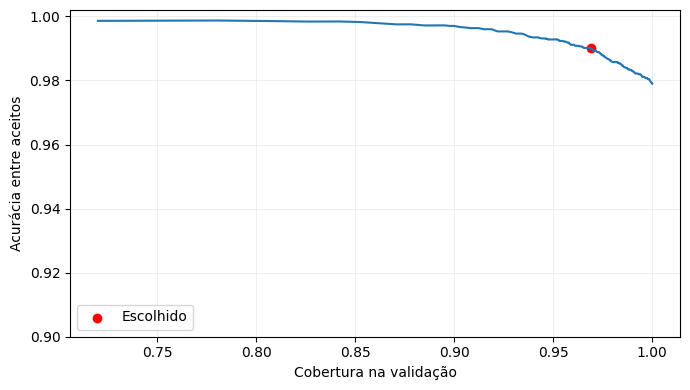

In [ ]:
p_val=modelo.predict(x_val[...,None],batch_size=256,verbose=0)
pred_val=p_val.argmax(1); conf_val=p_val.max(1); correto=pred_val==y_val
candidatos=[]
for limiar in np.linspace(.10,.999,900):
    aceito=conf_val>=limiar
    if aceito.any(): candidatos.append((limiar,correto[aceito].mean(),aceito.mean(),aceito.sum()))
tabela_lim=pd.DataFrame(candidatos,columns=['limiar','acuracia_aceitos','cobertura','n_aceitos'])
elegiveis=tabela_lim[(tabela_lim.acuracia_aceitos>=.99)&(tabela_lim.cobertura>=.50)]
if len(elegiveis): escolhido=elegiveis.iloc[0]
else:
    viaveis=tabela_lim[tabela_lim.cobertura>=.50]
    if not len(viaveis): viaveis=tabela_lim
    escolhido=viaveis.sort_values(['acuracia_aceitos','cobertura'],ascending=False).iloc[0]
LIMIAR=float(escolhido.limiar)
calibracao={'limiar_revisao':LIMIAR,'acuracia_aceitos_validacao':float(escolhido.acuracia_aceitos),
            'cobertura_validacao':float(escolhido.cobertura),'criterio':'alvo 99% e cobertura >=50%'}
salvar_json(PASTA/'limiar.json',calibracao)
print(calibracao)
plt.figure(figsize=(7,4)); plt.plot(tabela_lim.cobertura,tabela_lim.acuracia_aceitos)
plt.scatter([escolhido.cobertura],[escolhido.acuracia_aceitos],color='red',label='Escolhido')
plt.xlabel('Cobertura na validação'); plt.ylabel('Acurácia entre aceitos'); plt.ylim(.9,1.002)
plt.grid(alpha=.2); plt.legend(); plt.tight_layout(); plt.savefig(PASTA/'limiar.png',dpi=150); plt.show()


## 🧪 Passo 8 — Avaliação final no teste

Agora usamos o teste uma única vez. Apresentamos acurácia geral, matriz de confusão, precisão,
recall e F1 por dígito. Também separamos resultados aceitos e encaminhados para revisão.


RESULTADO FINAL: {'acuracia': 0.9819, 'acuracia_aceitos': 0.9933175696514855, 'cobertura_aceitos': 0.9727, 'encaminhados_revisao': 273, 'n_teste': 10000, 'modelo_sha256': 'c1a6d22ad66a7a5c5248e527ff7627f635451799f417a7a52317122baff5cc2d'}


,precision,recall,f1-score,support
0,0.9898,0.9888,0.9893,980.0000
1,0.9973,0.9868,0.9920,1135.0000
2,0.9752,0.9922,0.9837,1032.0000
3,0.9654,0.9931,0.9790,1010.0000
4,0.9759,0.9878,0.9818,982.0000
5,0.9843,0.9832,0.9837,892.0000
6,0.9915,0.9708,0.9810,958.0000
7,0.9911,0.9747,0.9828,1028.0000
8,0.9685,0.9784,0.9734,974.0000
9,0.9798,0.9623,0.9710,1009.0000


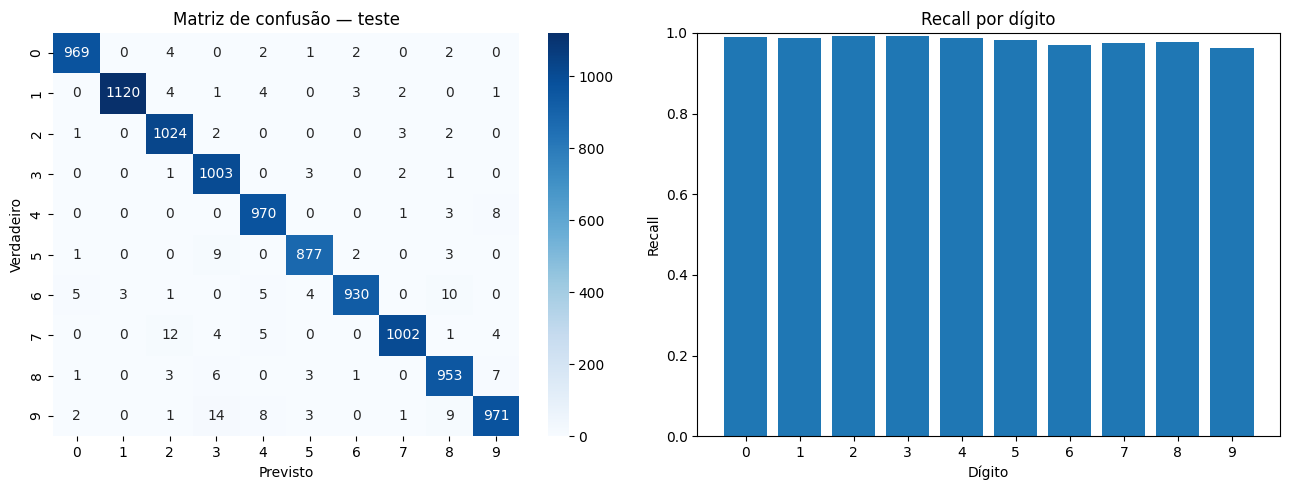

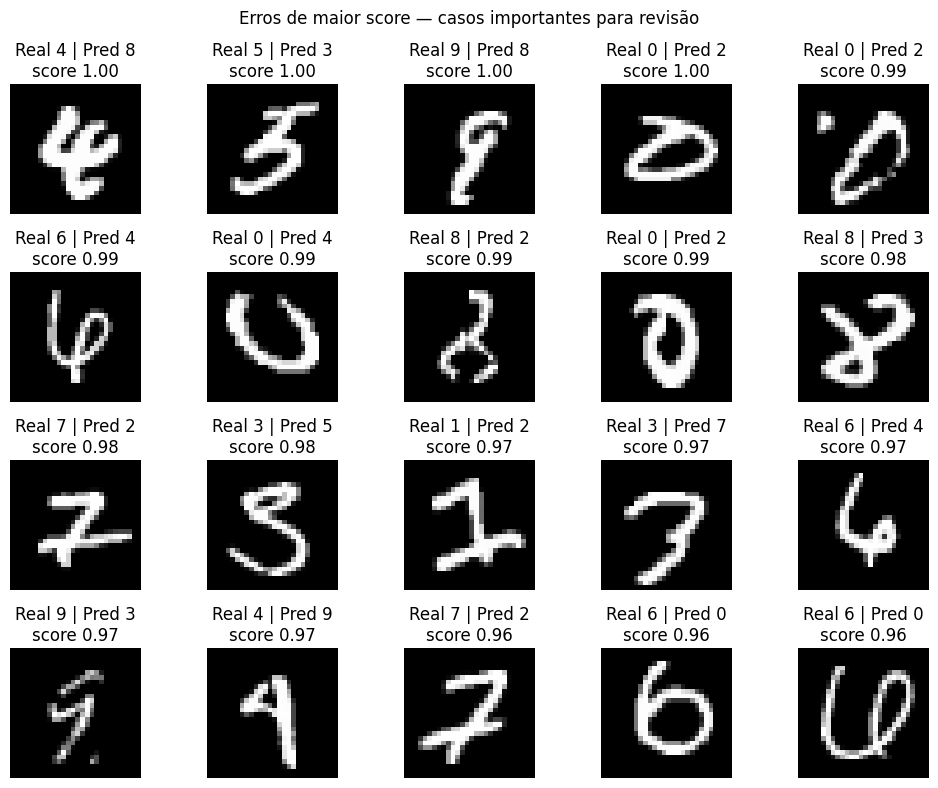

In [ ]:
p_teste=modelo.predict(x_teste[...,None],batch_size=256,verbose=0)
pred=p_teste.argmax(1); conf=p_teste.max(1); aceito=conf>=LIMIAR
cm=confusion_matrix(y_teste,pred)
relatorio=pd.DataFrame(classification_report(y_teste,pred,output_dict=True,zero_division=0)).T
relatorio.to_csv(PASTA/'relatorio_teste.csv')
resumo_teste={'acuracia':float((pred==y_teste).mean()),
              'acuracia_aceitos':float((pred[aceito]==y_teste[aceito]).mean()) if aceito.any() else None,
              'cobertura_aceitos':float(aceito.mean()),'encaminhados_revisao':int((~aceito).sum()),
              'n_teste':len(y_teste),'modelo_sha256':sha256(MODELO_FINAL)}
salvar_json(PASTA/'resultado_teste.json',resumo_teste)
print('RESULTADO FINAL:',resumo_teste); display(relatorio.round(4))

fig,axs=plt.subplots(1,2,figsize=(13,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axs[0])
axs[0].set(xlabel='Previsto',ylabel='Verdadeiro',title='Matriz de confusão — teste')
por_classe=np.diag(cm)/cm.sum(1)
axs[1].bar(range(10),por_classe); axs[1].set(xticks=range(10),ylim=(0,1),
    xlabel='Dígito',ylabel='Recall',title='Recall por dígito')
plt.tight_layout(); plt.savefig(PASTA/'matriz_confusao.png',dpi=150); plt.show()

erros=np.flatnonzero(pred!=y_teste)
erros=erros[np.argsort(-conf[erros])][:20]
fig,axs=plt.subplots(4,5,figsize=(10,8))
for ax,idx in zip(axs.flat,erros):
    ax.imshow(x_teste[idx],cmap='gray'); ax.axis('off')
    ax.set_title(f'Real {y_teste[idx]} | Pred {pred[idx]}\nscore {conf[idx]:.2f}')
plt.suptitle('Erros de maior score — casos importantes para revisão'); plt.tight_layout();
plt.savefig(PASTA/'erros.png',dpi=150); plt.show()


## 💾 Passo 9 — Recarregar sem treinar

Em uma nova sessão, execute o passo 1 e esta célula. Informe a pasta impressa no passo 2.
Deixando vazio, o notebook busca a execução concluída mais recente.


In [ ]:
PASTA_MODELO=''  # Ex.: /content/drive/MyDrive/DigitCheck/20260914_180000
raiz=Path('/content/drive/MyDrive/DigitCheck')
if PASTA_MODELO: pasta_modelo=Path(PASTA_MODELO)
else:
    concluidas=sorted(p.parent for p in raiz.glob('*/melhor_modelo.keras') if (p.parent/'limiar.json').exists())
    if not concluidas: raise FileNotFoundError('Informe PASTA_MODELO.')
    pasta_modelo=concluidas[-1]
arquivo_modelo=pasta_modelo/'melhor_modelo.keras'
modelo_dc=tf.keras.models.load_model(arquivo_modelo,compile=False)
LIMIAR_DC=json.loads((pasta_modelo/'limiar.json').read_text())['limiar_revisao']
assert modelo_dc.input_shape[1:]==(28,28,1) and modelo_dc.output_shape[-1]==10
print('✅ Modelo carregado:',arquivo_modelo)
print('Limiar de revisão:',round(LIMIAR_DC,3))


✅ Modelo carregado: /content/drive/MyDrive/DigitCheck/20260913_214546_591417/melhor_modelo.keras
Limiar de revisão: 0.805


## 📷 Passo 10 — Enviar e ler campos numéricos

Escreva algarismos escuros e separados em uma única linha sobre papel claro. Fotografe de frente,
recorte próximo ao campo e evite sombras. O OpenCV binariza a foto, encontra os componentes da
esquerda para a direita e prepara cada recorte no padrão do MNIST.

Dígitos encostados podem virar um único componente; sinais, bordas e pautas podem ser confundidos
com dígitos. Por isso a imagem processada e cada recorte são mostrados antes da confirmação.


Saving WhatsApp Image 2026-09-13 at 19.32.46.jpeg to WhatsApp Image 2026-09-13 at 19.32.46 (1).jpeg
Saving WhatsApp Image 2026-09-13 at 19.30.43 (2).jpeg to WhatsApp Image 2026-09-13 at 19.30.43 (2) (1).jpeg
Saving WhatsApp Image 2026-09-13 at 19.30.43 (1).jpeg to WhatsApp Image 2026-09-13 at 19.30.43 (1) (1).jpeg
Saving WhatsApp Image 2026-09-13 at 19.30.43.jpeg to WhatsApp Image 2026-09-13 at 19.30.43 (3).jpeg
Saving WhatsApp Image 2026-09-13 at 19.30.42.jpeg to WhatsApp Image 2026-09-13 at 19.30.42 (1).jpeg


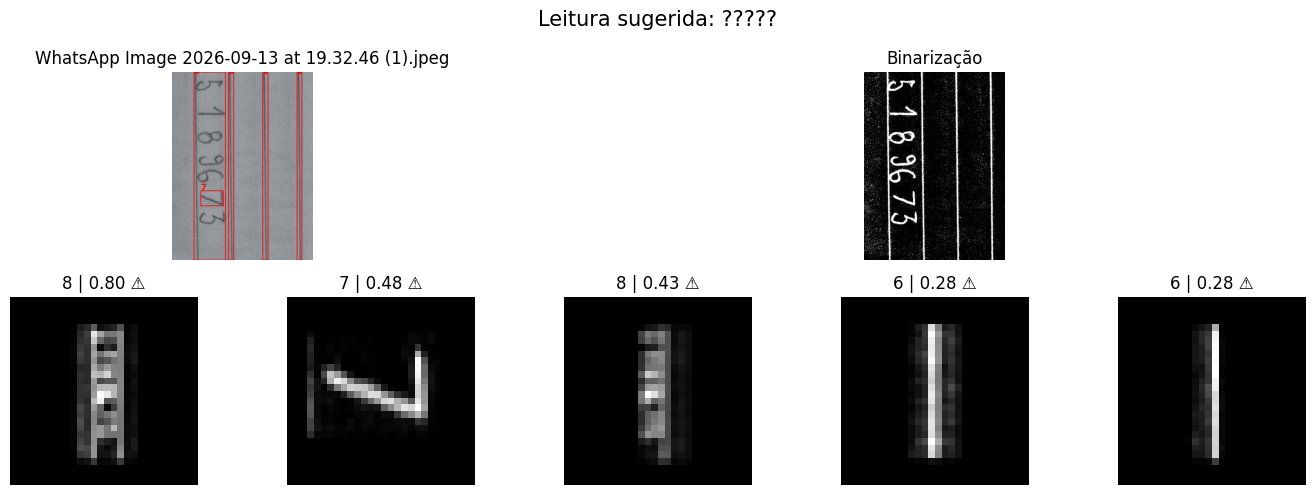

Resultado: ????? | revisar posições: [1, 2, 3, 4, 5]


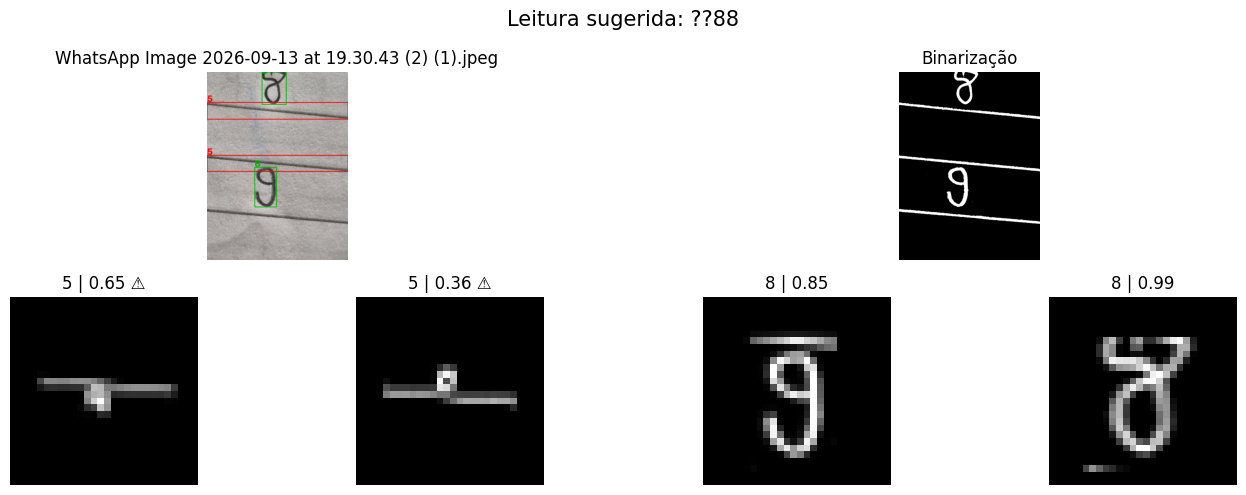

Resultado: ??88 | revisar posições: [1, 2]


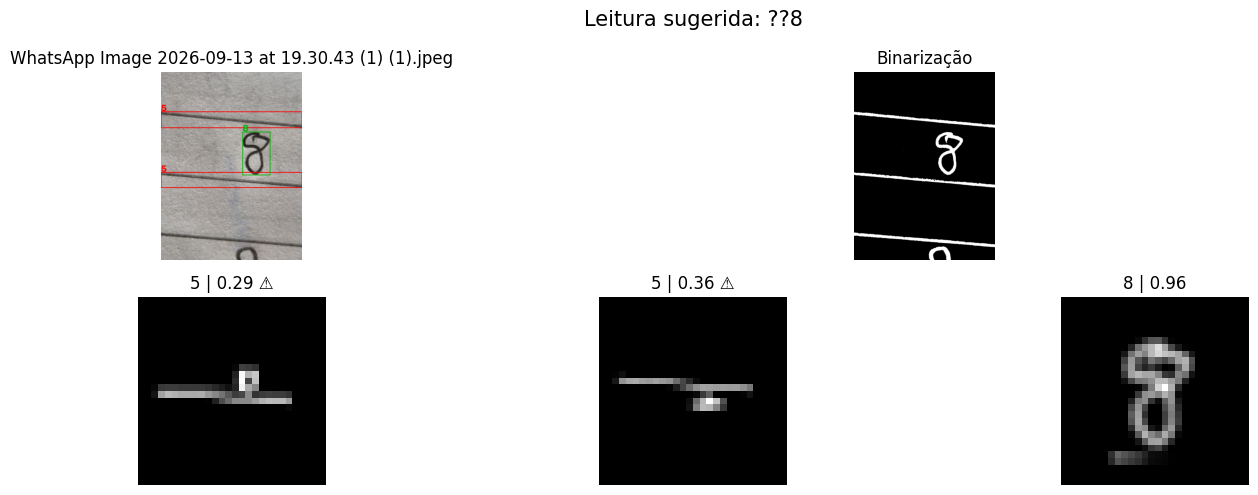

Resultado: ??8 | revisar posições: [1, 2]


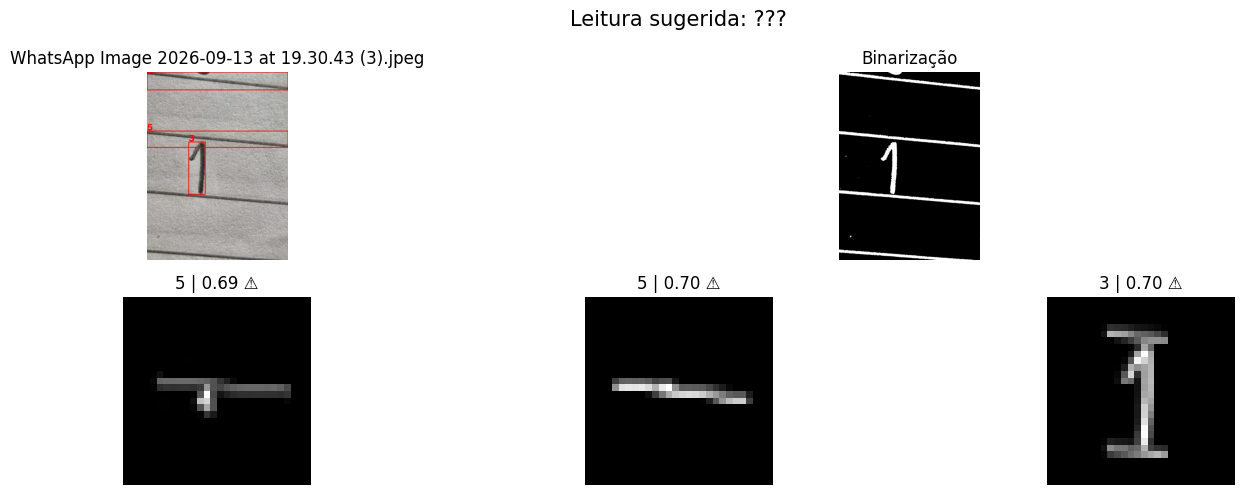

Resultado: ??? | revisar posições: [1, 2, 3]


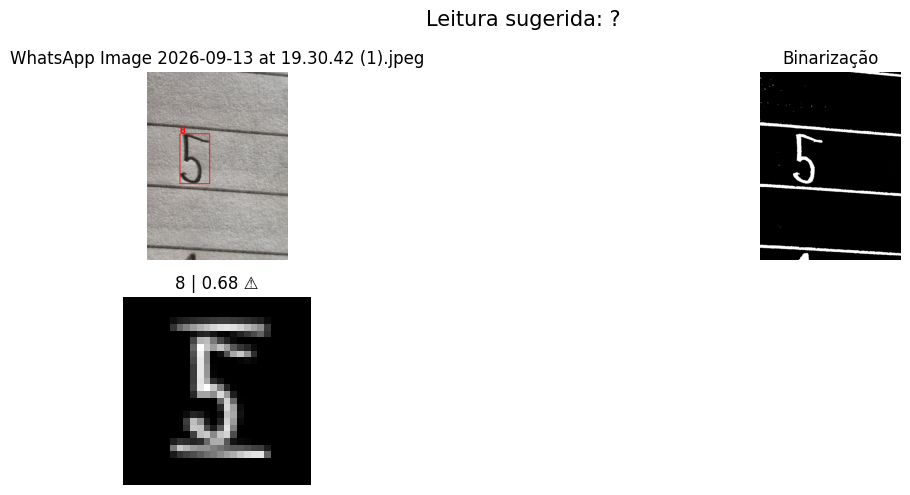

Resultado: ? | revisar posições: [1]
Resultados visuais salvos em: /content/drive/MyDrive/DigitCheck/20260913_214546_591417/leituras/20260913_224035_511484


In [19]:
def preparar_recorte(binario,x,y,w,h):
    margem=max(2,round(.15*max(w,h)))
    y0=max(0,y-margem); y1=min(binario.shape[0],y+h+margem)
    x0=max(0,x-margem); x1=min(binario.shape[1],x+w+margem)
    rec=binario[y0:y1,x0:x1]
    escala=20/max(rec.shape)
    nw=max(1,round(rec.shape[1]*escala)); nh=max(1,round(rec.shape[0]*escala))
    pequeno=cv2.resize(rec,(nw,nh),interpolation=cv2.INTER_AREA)
    tela=np.zeros((28,28),dtype=np.uint8)
    oy=(28-nh)//2; ox=(28-nw)//2; tela[oy:oy+nh,ox:ox+nw]=pequeno
    m=cv2.moments(tela)
    if m['m00']:
        cx=m['m10']/m['m00']; cy=m['m01']/m['m00']
        M=np.float32([[1,0,13.5-cx],[0,1,13.5-cy]])
        tela=cv2.warpAffine(tela,M,(28,28),borderValue=0)
    return tela

def extrair_digitos(imagem):
    imagem=ImageOps.exif_transpose(imagem).convert('RGB')
    arr=np.asarray(imagem)
    if max(arr.shape[:2])>1600:
        e=1600/max(arr.shape[:2]); arr=cv2.resize(arr,None,fx=e,fy=e,interpolation=cv2.INTER_AREA)
    cinza=cv2.cvtColor(arr,cv2.COLOR_RGB2GRAY)
    borda=np.concatenate([cinza[0],cinza[-1],cinza[:,0],cinza[:,-1]])
    if np.median(borda)<127: cinza=255-cinza
    cinza=cv2.GaussianBlur(cinza,(3,3),0)
    _,binario=cv2.threshold(cinza,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
    contornos,_=cv2.findContours(binario,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    area_total=binario.shape[0]*binario.shape[1]
    caixas=[]
    for c in contornos:
        x,y,w,h=cv2.boundingRect(c)
        if w*h>=area_total*.001 and h>=binario.shape[0]*.08: caixas.append((x,y,w,h))
    caixas.sort(key=lambda b:b[0])
    if not caixas: raise ValueError('Nenhum dígito encontrado. Recorte a foto e aumente o contraste.')
    return arr,binario,caixas,[preparar_recorte(binario,*b) for b in caixas]

enviados=files.upload()
if not enviados: raise ValueError('Nenhuma imagem enviada.')
PASTA_FOTOS=pasta_modelo/'leituras'/datetime.now().strftime('%Y%m%d_%H%M%S_%f')
PASTA_FOTOS.mkdir(parents=True,exist_ok=True)
leituras=[]
for numero,(nome,conteudo) in enumerate(enviados.items()):
    try: original,binario,caixas,recortes=extrair_digitos(Image.open(io.BytesIO(conteudo)))
    except Exception as e: print('❌',nome,':',e); continue
    p=modelo_dc.predict(np.array(recortes)[...,None],verbose=0)
    digitos=p.argmax(1); scores=p.max(1); revisar=scores<LIMIAR_DC
    leitura=''.join('?' if r else str(d) for d,r in zip(digitos,revisar))
    prefixo=f'{numero:02d}_'+re.sub(r'[^a-zA-Z0-9_-]+','_',Path(nome).stem)[:50]
    marcado=original.copy()
    for i,(x,y,w,h) in enumerate(caixas):
        cor=(255,0,0) if revisar[i] else (0,180,0)
        cv2.rectangle(marcado,(x,y),(x+w,y+h),cor,max(1,original.shape[0]//250))
        cv2.putText(marcado,str(digitos[i]),(x,max(15,y-5)),cv2.FONT_HERSHEY_SIMPLEX,
                    max(.5,original.shape[0]/600),cor,2)
    Image.fromarray(original).save(PASTA_FOTOS/f'{prefixo}_original.jpg')
    Image.fromarray(binario).save(PASTA_FOTOS/f'{prefixo}_binario.png')
    Image.fromarray(marcado).save(PASTA_FOTOS/f'{prefixo}_marcado.jpg')
    leituras.append({'arquivo':nome,'leitura_sugerida':leitura,
                     'previsoes':''.join(map(str,digitos)),'scores':scores.tolist(),
                     'posicoes_revisar':(np.flatnonzero(revisar)+1).tolist(),'n_digitos':len(digitos)})
    fig=plt.figure(figsize=(14,5)); gs=fig.add_gridspec(2,max(2,len(recortes)))
    ax1=fig.add_subplot(gs[0,:len(recortes)//2 or 1]); ax1.imshow(marcado); ax1.axis('off'); ax1.set_title(nome)
    ax2=fig.add_subplot(gs[0,len(recortes)//2 or 1:]); ax2.imshow(binario,cmap='gray'); ax2.axis('off'); ax2.set_title('Binarização')
    for i,rec in enumerate(recortes):
        ax=fig.add_subplot(gs[1,i]); ax.imshow(rec,cmap='gray'); ax.axis('off')
        ax.set_title(f'{digitos[i]} | {scores[i]:.2f}'+(' ⚠' if revisar[i] else ''))
    plt.suptitle(f'Leitura sugerida: {leitura}',fontsize=15); plt.tight_layout(); plt.show()
    print('Resultado:',leitura,'| revisar posições:',(np.flatnonzero(revisar)+1).tolist() or 'nenhuma pelo limiar')
print('Resultados visuais salvos em:',PASTA_FOTOS)


## ✅ Passo 11 — Avaliação crítica do teste com fotografias reais

Nos testes realizados com fotografias externas, nenhuma sequência numérica foi reconhecida completamente. Portanto, considerando como acerto somente uma leitura integralmente correta, a **acurácia exata observada foi de 0%**.

Apesar desse resultado, as imagens mostram que o classificador conseguiu reconhecer corretamente alguns algarismos isolados. Por exemplo, um dos números 8 foi classificado como 8 com confiança de 0,96. Isso indica que o modelo treinado não falhou completamente: o maior problema ocorreu na etapa anterior à classificação, responsável por localizar e recortar os números.

Nas fotografias, os algarismos foram escritos sobre uma folha pautada. Durante a binarização, as linhas do caderno também ficaram destacadas em branco. O algoritmo de contornos interpretou partes dessas linhas como se fossem algarismos e, em alguns casos, produziu recortes contendo simultaneamente um número e uma linha horizontal ou vertical. Nos resultados apresentados, é possível observar vários desses recortes inválidos sendo enviados ao modelo.

Esse problema afetou o sistema de três maneiras:

1. algumas linhas do papel foram detectadas como números;
2. alguns algarismos verdadeiros não foram localizados corretamente;
3. vários recortes continham partes das linhas junto com o algarismo.

Além disso, existe uma diferença importante entre os dados de treinamento e as imagens reais. O MNIST contém algarismos isolados, centralizados, em resolução 28 × 28 e com fundo preto uniforme. Já as fotografias utilizadas apresentam linhas de caderno, iluminação irregular, perspectiva, rotação, diferentes espessuras de escrita e sequências com vários números.

Quando um recorte inválido é enviado à rede neural, ela ainda precisa escolher obrigatoriamente uma das classes de 0 a 9, pois não existe uma classe chamada “não é um número”. Por isso, elementos como linhas do papel foram classificados como 5, 6 ou 7, às vezes com confiança aparentemente elevada. O limiar de confiança marcou várias posições com “?”, mas não conseguiu corrigir a origem do problema.

Assim, a avaliação externa revelou que uma acurácia elevada no conjunto de teste do MNIST não garante o funcionamento do produto em fotografias reais. O classificador aprendeu a reconhecer imagens semelhantes ao MNIST, mas o sistema completo não foi suficientemente robusto para separar algarismos manuscritos das linhas e demais interferências presentes no cenário real.

### Conclusão do teste externo

O DigitCheck deve ser considerado um **protótipo experimental**. Ele demonstra corretamente o treinamento, a avaliação e o uso de uma rede neural com TensorFlow/Keras, mas sua aplicação em fotografias reais exige melhorias na segmentação e dados de treinamento mais próximos do ambiente de utilização. O resultado negativo não foi ocultado: ele foi utilizado para identificar, de forma objetiva, a principal limitação do produto.

### 🔢 Interpretação da matriz de confusão

A matriz de confusão mostra que o modelo teve um desempenho muito bom no conjunto de teste do MNIST, alcançando aproximadamente **98,2% de acurácia**. A grande concentração de valores na diagonal principal significa que a maioria dos dígitos foi classificada corretamente.

Mesmo nesse ambiente controlado, algumas confusões permaneceram. Entre os erros mais frequentes, destacam-se:

- o dígito 9 confundido com 3;
- o dígito 7 confundido com 2;
- o dígito 6 confundido com 8;
- o dígito 5 confundido com 3;
- confusões entre os dígitos 8 e 9.

Esses erros são compreensíveis porque alguns algarismos manuscritos possuem formatos visualmente semelhantes. O gráfico de recall também mostra resultados elevados para todas as classes, embora o dígito 9 tenha apresentado o menor desempenho relativo.

Outro resultado importante é a existência de classificações erradas com confiança próxima de 1,00. Foram encontrados, por exemplo, casos em que o número verdadeiro era 4 e o modelo previu 8 com confiança de 1,00. Isso demonstra que o valor de confiança representa o quanto o modelo favoreceu uma classe, mas **não garante que a resposta esteja correta**.

A matriz de confusão e os testes externos avaliam situações diferentes. A matriz utiliza imagens do próprio MNIST, semelhantes às usadas no treinamento, enquanto as fotografias externas possuem linhas, sombras, rotação e perspectiva. Portanto, não existe contradição entre os aproximadamente 98,2% obtidos no teste e os erros observados nas fotos reais: o modelo apresentou bom desempenho dentro do domínio do MNIST, mas não generalizou satisfatoriamente para um ambiente diferente.